# Experiment 5.0 — Local-evidence objective × event-capacity analysis

Analysis-only notebook. Training/evaluation is performed by the Slurm pipeline.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks/artifacts/experiment_5_0_local_evidence_objectives/local_objective_x_event_capacity_v1'
RUNS = pd.read_csv(ROOT / 'runs.csv')
SUMMARY = pd.read_csv(ROOT / 'summary.csv')
LOSS_EFFECTS = pd.read_csv(ROOT / 'paired_loss_effects_summary.csv')
VARIANT_EFFECTS = pd.read_csv(ROOT / 'paired_variant_effects_summary.csv')
MANIFEST = json.loads((ROOT / 'manifest.json').read_text(encoding='utf-8'))
MANIFEST


{'architecture': {'input_channels': 30,
  'l1_group_neurons': [43, 43, 42],
  'l1_shifts': [2, 3, 4],
  'l1_tau_syn_ms': [54.31342963722199, 117.0136826471659, 242.10347130039656],
  'l1_width': 128,
  'l2_group_neurons': [43, 43, 42],
  'l2_shifts': [2, 3, 4],
  'l2_tau_syn_ms': [54.31342963722199, 117.0136826471659, 242.10347130039656],
  'l2_width': 128,
  'logit_gain_training_only': 5.0,
  'output_neurons': 12,
  'output_synaptic_state': False,
  'output_tau_mem_ms': 22.54,
  'reset': 'subtract',
  'sampling_rate_hz': 64.0,
  'tau_mem_ms': 22.54,
  'threshold': 0.5},
 'checkpoint_selection': 'validation Output WholeCount BA for every training objective',
 'experiment_id': 'experiment_5_0_local_evidence_objectives',
 'files': {'paired_loss_effects': 'paired_loss_effects.csv',
  'paired_loss_effects_summary': 'paired_loss_effects_summary.csv',
  'paired_variant_effects': 'paired_variant_effects.csv',
  'paired_variant_effects_summary': 'paired_variant_effects_summary.csv',
  'runs': 

## Primary deployment result — Output WholeCount

All training objectives are compared using the same final deployment readout.


,objective,variant,mean,std
14,whole_count_ce,multi_ho,0.512250,0.043633
5,fixed500_bin_ce,multi_ho,0.505814,0.026220
12,whole_count_ce,binary,0.505107,0.031606
8,relative10_bin_ce,multi_ho,0.496484,0.029791
2,fixed250_bin_ce,multi_ho,0.495350,0.013139
11,timestep_ce,multi_ho,0.482136,0.014762
13,whole_count_ce,multi_h,0.480388,0.013605
6,relative10_bin_ce,binary,0.458741,0.030848
0,fixed250_bin_ce,binary,0.449537,0.027743
3,fixed500_bin_ce,binary,0.443098,0.021388


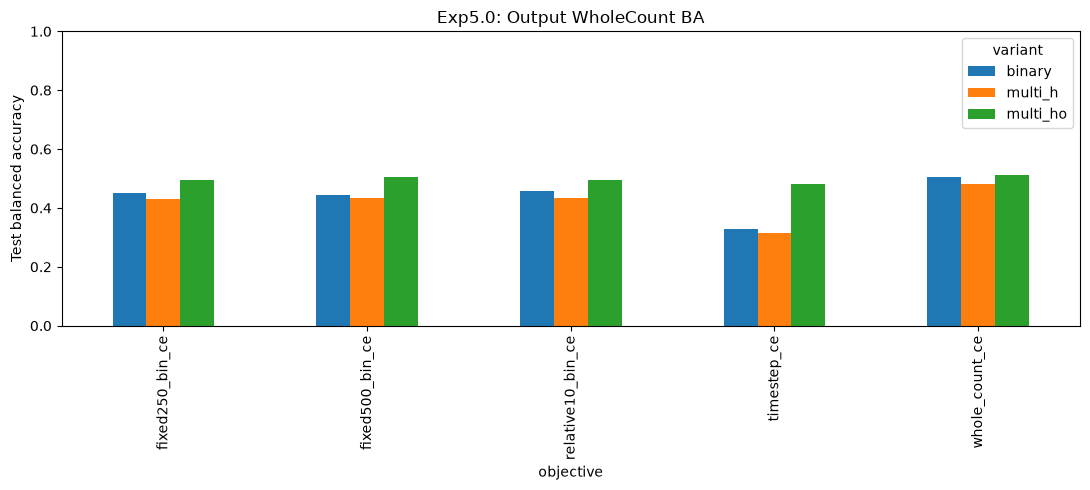

In [2]:
test = RUNS[RUNS['split'] == 'test'].copy()
primary = test.groupby(['objective','variant'])['output_whole_count_ba'].agg(['mean','std']).reset_index()
display(primary.sort_values('mean', ascending=False))
pivot = primary.pivot(index='objective', columns='variant', values='mean')
ax = pivot.plot(kind='bar', figsize=(11,5))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp5.0: Output WholeCount BA')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Hidden local-evidence quality — L2 WholeCount + Linear


,objective,variant,mean,std
11,timestep_ce,multi_ho,0.577823,0.035291
14,whole_count_ce,multi_ho,0.570903,0.031781
5,fixed500_bin_ce,multi_ho,0.569855,0.016059
8,relative10_bin_ce,multi_ho,0.566503,0.012933
2,fixed250_bin_ce,multi_ho,0.549865,0.039019
13,whole_count_ce,multi_h,0.531356,0.035822
12,whole_count_ce,binary,0.529180,0.017066
7,relative10_bin_ce,multi_h,0.499069,0.048382
0,fixed250_bin_ce,binary,0.492244,0.016701
3,fixed500_bin_ce,binary,0.490662,0.024953


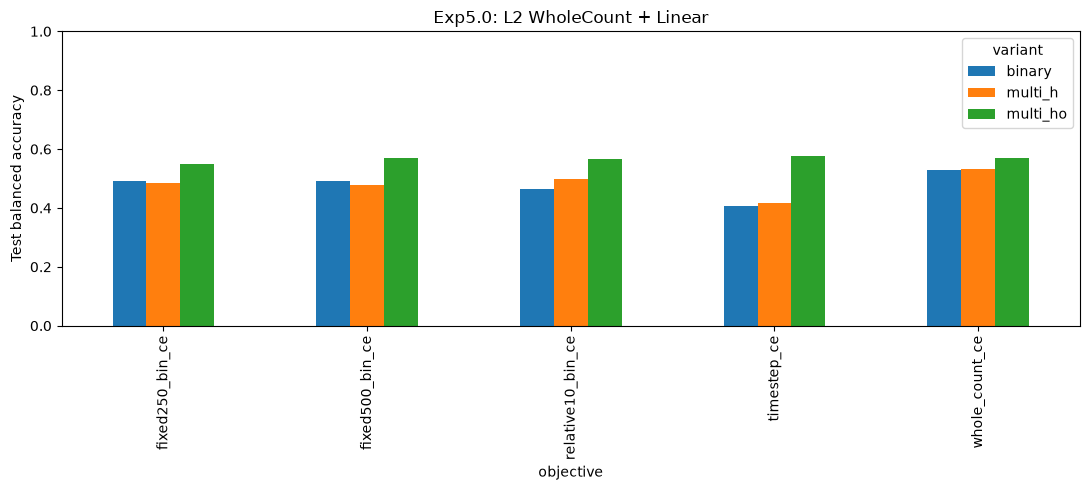

In [3]:
hidden = test.groupby(['objective','variant'])['l2_whole_count_linear_ba'].agg(['mean','std']).reset_index()
display(hidden.sort_values('mean', ascending=False))
pivot = hidden.pivot(index='objective', columns='variant', values='mean')
ax = pivot.plot(kind='bar', figsize=(11,5))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp5.0: L2 WholeCount + Linear')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Readout compression matrix

Compare phase-aware external Linear probes, orderless hidden WholeCount + Linear, endpoint membrane, and the 12-neuron Output WholeCount.


In [4]:
readout_cols = {
    'Output WholeCount': 'output_whole_count_ba',
    'L1 Count + Linear': 'l1_whole_count_linear_ba',
    'L2 Count + Linear': 'l2_whole_count_linear_ba',
    'L2 Fixed250 + Linear': 'l2_fixed250_ordered_linear_ba',
    'L2 Relative10 + Linear': 'l2_relative10_ordered_linear_ba',
    'L2 Uend + Linear': 'l2_uend_linear_ba',
}
matrix_rows = []
for (objective, variant), part in test.groupby(['objective','variant']):
    row = {'objective': objective, 'variant': variant}
    for label, column in readout_cols.items():
        row[label] = part[column].mean()
    matrix_rows.append(row)
READOUT_MATRIX = pd.DataFrame(matrix_rows)
display(READOUT_MATRIX)


,objective,variant,Output WholeCount,L1 Count + Linear,L2 Count + Linear,L2 Fixed250 + Linear,L2 Relative10 + Linear,L2 Uend + Linear
0,fixed250_bin_ce,binary,0.449537,0.491339,0.492244,0.475814,0.599916,0.374746
1,fixed250_bin_ce,multi_h,0.429202,0.431650,0.484797,0.461343,0.597537,0.278873
2,fixed250_bin_ce,multi_ho,0.495350,0.514669,0.549865,0.534957,0.653361,0.205612
3,fixed500_bin_ce,binary,0.443098,0.453348,0.490662,0.521178,0.615399,0.378077
4,fixed500_bin_ce,multi_h,0.434043,0.463688,0.478458,0.466481,0.594518,0.281803
5,fixed500_bin_ce,multi_ho,0.505814,0.546059,0.569855,0.545494,0.674362,0.221420
6,relative10_bin_ce,binary,0.458741,0.469811,0.464020,0.495502,0.597203,0.354306
7,relative10_bin_ce,multi_h,0.433695,0.442884,0.499069,0.468357,0.574273,0.297230
8,relative10_bin_ce,multi_ho,0.496484,0.550359,0.566503,0.543891,0.659384,0.223196
9,timestep_ce,binary,0.328668,0.417251,0.405939,0.393515,0.477558,0.340611


## Paired objective effects vs WholeCount CE


In [5]:
display(LOSS_EFFECTS.sort_values(['readout','variant','mean'], ascending=[True,True,False]))


,objective,variant,readout,mean,std,count
0,fixed250_bin_ce,binary,l1_whole_count_linear,-0.008645,0.023820,5
36,relative10_bin_ce,binary,l1_whole_count_linear,-0.030172,0.045228,5
18,fixed500_bin_ce,binary,l1_whole_count_linear,-0.046636,0.020313,5
54,timestep_ce,binary,l1_whole_count_linear,-0.082733,0.057485,5
24,fixed500_bin_ce,multi_h,l1_whole_count_linear,-0.021144,0.057506,5
...,...,...,...,...,...,...
65,timestep_ce,multi_h,output_whole_count,-0.164865,0.028864,5
35,fixed500_bin_ce,multi_ho,output_whole_count,-0.006435,0.043604,5
53,relative10_bin_ce,multi_ho,output_whole_count,-0.015766,0.038123,5
17,fixed250_bin_ce,multi_ho,output_whole_count,-0.016900,0.051291,5


## Paired event-capacity effects


In [6]:
display(VARIANT_EFFECTS.sort_values(['readout','objective','mean'], ascending=[True,True,False]))


,objective,candidate_variant,baseline_variant,readout,mean,std,count
12,fixed250_bin_ce,multi_ho,multi_h,l1_whole_count_linear,0.083018,0.051953,5
6,fixed250_bin_ce,multi_ho,binary,l1_whole_count_linear,0.023329,0.052752,5
0,fixed250_bin_ce,multi_h,binary,l1_whole_count_linear,-0.059689,0.037564,5
24,fixed500_bin_ce,multi_ho,binary,l1_whole_count_linear,0.092711,0.023686,5
30,fixed500_bin_ce,multi_ho,multi_h,l1_whole_count_linear,0.082371,0.055801,5
...,...,...,...,...,...,...,...
65,timestep_ce,multi_ho,binary,output_whole_count,0.153468,0.027152,5
59,timestep_ce,multi_h,binary,output_whole_count,-0.013144,0.031224,5
89,whole_count_ce,multi_ho,multi_h,output_whole_count,0.031861,0.047171,5
83,whole_count_ce,multi_ho,binary,output_whole_count,0.007142,0.064771,5


## Event cost and persistence


,objective,variant,l1_events_per_neuron_second,l2_events_per_neuron_second,output_events_per_neuron_second,l1_tail_event_fraction,l2_tail_event_fraction,output_tail_event_fraction
0,fixed250_bin_ce,binary,1.428222,8.252618,6.708019,0.035831,0.175870,0.241400
1,fixed250_bin_ce,multi_h,1.205807,14.254225,5.271217,0.038208,0.174629,0.249629
2,fixed250_bin_ce,multi_ho,4.991021,166.824354,330.491981,0.059057,0.220543,0.272695
3,fixed500_bin_ce,binary,1.457389,8.975812,7.441308,0.036287,0.181140,0.259404
4,fixed500_bin_ce,multi_h,1.453512,18.925340,6.907002,0.040227,0.173300,0.240303
5,fixed500_bin_ce,multi_ho,5.415192,200.786763,360.806450,0.059130,0.218337,0.275310
6,relative10_bin_ce,binary,1.286514,7.288494,5.834858,0.033313,0.170899,0.236588
7,relative10_bin_ce,multi_h,1.229100,14.150688,4.658008,0.037072,0.171131,0.258099
8,relative10_bin_ce,multi_ho,4.963519,164.339795,322.669494,0.058992,0.222145,0.280437
9,timestep_ce,binary,0.707695,4.494640,1.502010,0.024185,0.146993,0.185031


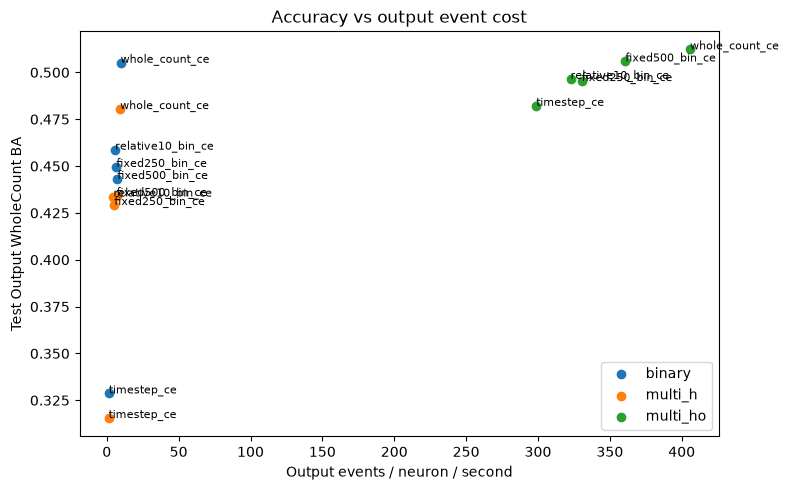

In [7]:
cost_cols = [
    'l1_events_per_neuron_second',
    'l2_events_per_neuron_second',
    'output_events_per_neuron_second',
    'l1_tail_event_fraction',
    'l2_tail_event_fraction',
    'output_tail_event_fraction',
]
display(test.groupby(['objective','variant'])[cost_cols].mean().reset_index())
cost = test.groupby(['objective','variant']).agg(
    ba=('output_whole_count_ba','mean'),
    output_rate=('output_events_per_neuron_second','mean'),
).reset_index()
fig, ax = plt.subplots(figsize=(8,5))
for variant, part in cost.groupby('variant'):
    ax.scatter(part.output_rate, part.ba, label=variant)
    for row in part.itertuples(index=False):
        ax.annotate(row.objective, (row.output_rate, row.ba), fontsize=8)
ax.set_xlabel('Output events / neuron / second')
ax.set_ylabel('Test Output WholeCount BA')
ax.set_title('Accuracy vs output event cost')
ax.legend()
plt.tight_layout()
plt.show()
